# TS2 - Transformada Discreta de Fourier (DFT)

Implementación de un algoritmo que calcula la DFT:

$$X_k = \sum_{n=0}^{N-1} x_n \cdot e^{-j\,2\pi\,k\,n/N}$$


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

plt.rcParams.update({
    "figure.figsize": (10, 4),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11
})

## Generador de señales (reutilizado de TS1)

In [2]:
class GeneradorSenales:

    @staticmethod
    def _resolver_parametros(ff, n, fs):
        """
        Resuelve fs y n en caso de no ser provistos
        (se trata de igualar fs y n, en caso de no haber valores de ambos -< se lleva a nyquist)
        """

        if fs is None and n is None:
            fs = ff * 2
            n = int(fs)

        elif fs is None:
            fs = n

        elif n is None:
            n = int(fs)

        return int(n), float(fs)

    @staticmethod
    def _generar_tiempo(n, fs):
        t = np.arange(n) / fs
        return t.reshape(-1, 1)

    @staticmethod
    def generar_seno(vmax=1, dc=0, ff=1, ph=0, n=None, fs=None):

        n, fs = GeneradorSenales._resolver_parametros(ff, n, fs)
        tt = GeneradorSenales._generar_tiempo(n, fs)

        xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)

        return tt, xx

    @staticmethod
    def generar_cuadrada(vmax=1, dc=0, ff=1, ph=0, n=None, fs=None):

        n, fs = GeneradorSenales._resolver_parametros(ff, n, fs)
        tt = GeneradorSenales._generar_tiempo(n, fs)

        xx = dc + vmax * np.sign(np.sin(2 * np.pi * ff * tt + ph))

        return tt, xx

    @staticmethod
    def generar_sawtooth(vmax=1, dc=0, ff=1, ph=0, n=None, fs=None):

        n, fs = GeneradorSenales._resolver_parametros(ff, n, fs)
        tt = GeneradorSenales._generar_tiempo(n, fs)

        # Fase expresada en ciclos
        fase_ciclos = ff * tt + ph / (2 * np.pi)

        rampa_01 = fase_ciclos - np.floor(fase_ciclos)

        # Escalar a -1 1
        xx = dc + vmax * (2 * rampa_01 - 1)

        return tt, xx

## Implementación de la DFT

La sumatoria se puede escribir como un producto matricial $X = W \cdot x$, donde $W_{k,n} = e^{-j\,2\pi\,k\,n/N}$ es la matriz DFT (Vandermonde de las raíces N-ésimas de la unidad). Vectorizando con NumPy queda mucho más rápido que dos loops anidados.

In [3]:
def mi_funcion_DFT(xx):
    """
    Calcula la DFT de una señal real.

    Parametros
    ----------
    xx : array_like (N,) o (N,1)
        Senial real a analizar.

    Retorna
    -------
    XX : ndarray (N,1) complejo
        DFT de xx.
    """
    x = np.asarray(xx, dtype=float)
    N = x.size

    n = np.arange(N)
    k = n.reshape(-1, 1)# Transpuesta
    n = n.reshape(1, -1)# convierto en matriz

    #@ = Producto matricial
    integer_matrix = k @ n
    W = np.exp(-1j * 2 * np.pi * integer_matrix / N)

    XX = W @ x
    return XX.reshape(-1, 1)

## Validación (senoidal)

se valida el funcionamiento de la DFT con el uso de una señal senoidal

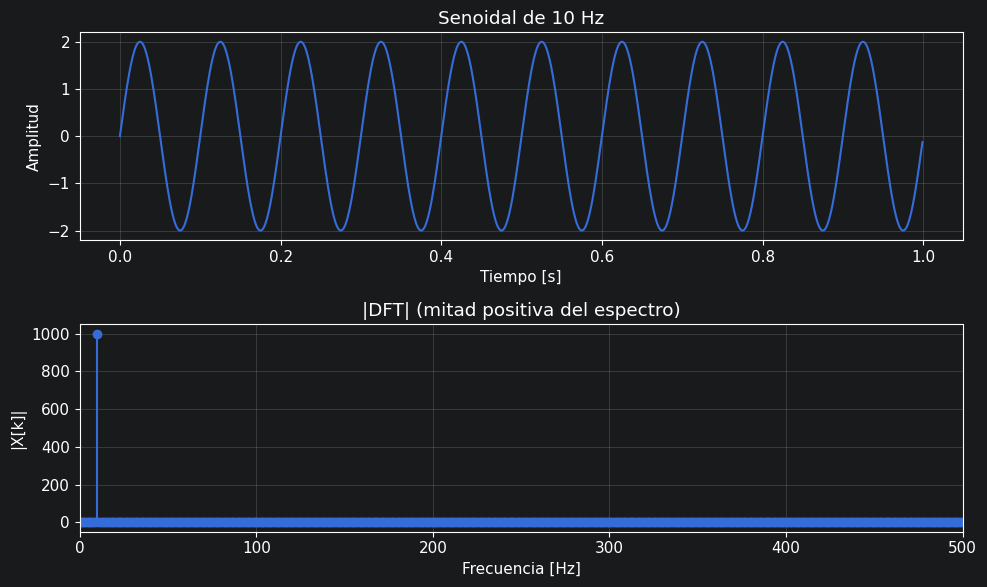

Pico esperado en k = 10 (f = 10.0 Hz)
|X[k0]| = 1000.0000   |   esperado A*N/2 = 500.0


In [4]:
N = 1000
fs = 1000
f0 = 10
A = 1.0

tt, xx = GeneradorSenales.generar_seno(vmax=A, ff=f0, n=N, fs=fs)
xx = 2* xx
XX = mi_funcion_DFT(xx)

freqs = np.arange(N) * fs / N
modulo = np.abs(XX)
modulo = modulo.flatten()

fig, axes = plt.subplots(2, 1, figsize=(10, 6))

axes[0].plot(tt, xx)
axes[0].set_title(f"Senoidal de {f0} Hz")
axes[0].set_xlabel("Tiempo [s]")
axes[0].set_ylabel("Amplitud")

axes[1].stem(freqs[:N//2], modulo[:N//2], basefmt=" ")
axes[1].set_title("|DFT| (mitad positiva del espectro)")
axes[1].set_xlabel("Frecuencia [Hz]")
axes[1].set_ylabel("|X[k]|")
axes[1].set_xlim(0, fs/2)

plt.tight_layout()
plt.show()

k0 = int(f0 * N / fs)
print(f"Pico esperado en k = {k0} (f = {freqs[k0]} Hz)")
print(f"|X[k0]| = {modulo[k0]:.4f}   |   esperado A*N/2 = {A*N/2}")

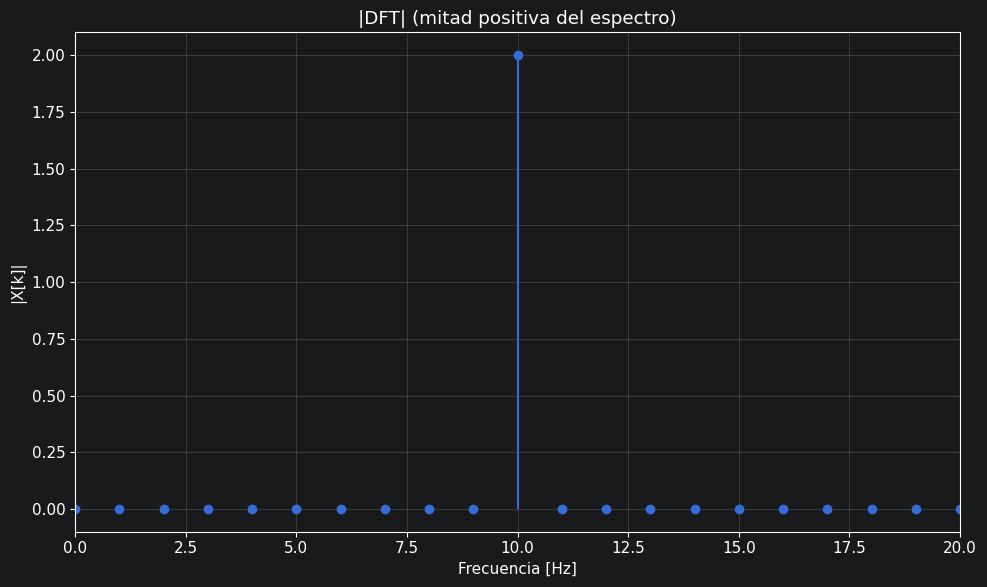

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

#Normalizo y muestro mitad de espectro
modulo_normalizado =  modulo[:N//2]* 2 / N
ax.stem(freqs[:N//2],modulo_normalizado, basefmt=" ")
ax.set_title("|DFT| (mitad positiva del espectro)")
ax.set_xlabel("Frecuencia [Hz]")
ax.set_ylabel("|X[k]|")

# Zoom en la frecuencia de interés
ax.set_xlim(0, 20)

plt.tight_layout()
plt.show()

##Comparación con FFT


Mi algoritmo de DFT tardo: 0.0719 s
La FFT tardo:              0.0183 s
La FFT es 3.9 veces mas rapida

Error maximo entre mi DFT y fft: 1.000e+03


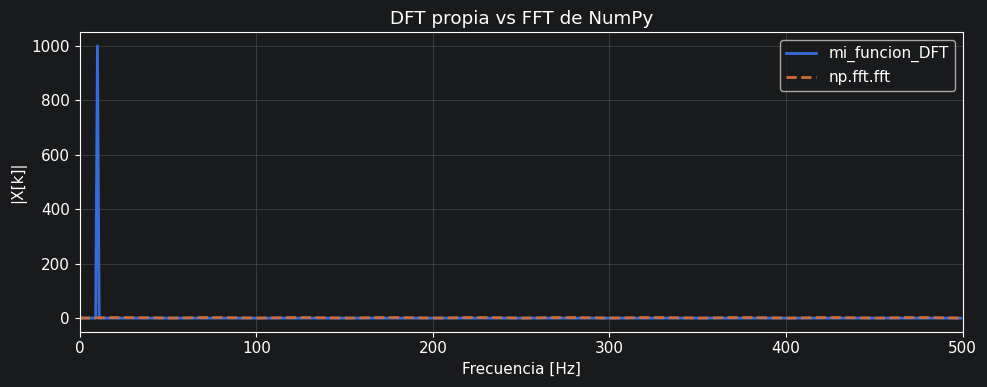

In [6]:
inicio_midft = time.perf_counter()
XX_mia = mi_funcion_DFT(xx)
fin_midft = time.perf_counter()

inicio_fft = time.perf_counter()
XX_fft = np.fft.fft(xx)
fin_fft = time.perf_counter()

t_mia = fin_midft - inicio_midft
t_fft = fin_fft - inicio_fft
print(f"Mi algoritmo de DFT tardo: {t_mia:.4f} s")
print(f"La FFT tardo:              {t_fft:.4f} s")
print(f"La FFT es {t_mia/t_fft:.1f} veces mas rapida")

print()
error_max = np.max(np.abs(XX_mia - XX_fft))
print(f"Error maximo entre mi DFT y fft: {error_max:.3e}")

fig, ax = plt.subplots()
ax.plot(freqs[:N//2], np.abs(XX_mia[:N//2]), label="mi_funcion_DFT", linewidth=2)
ax.plot(freqs[:N//2], np.abs(XX_fft[:N//2]), "--", label="np.fft.fft", linewidth=2)
ax.set_xlabel("Frecuencia [Hz]")
ax.set_ylabel("|X[k]|")
ax.set_title("DFT propia vs FFT de NumPy")
ax.set_xlim(0, fs/2)
ax.legend()
plt.tight_layout()
plt.show()

Comparación de velocidad (la diferencia se vuelve enorme cuando $N$ crece):

In [7]:
import time

def medir(func, repeticiones=5):
    t0 = time.perf_counter()
    func()
    tiempo = time.perf_counter() - t0
    return tiempo

for Nb in [256, 1024, 4096]:
    _, x_b = GeneradorSenales.generar_seno(ff=10, n=Nb, fs=Nb)

    t_dft = medir(lambda: mi_funcion_DFT(x_b))
    t_fft = medir(lambda: np.fft.fft(x_b))

    print(f"N = {Nb:5d}  ->  DFT: {t_dft*1e3:8.3f} ms   "
          f"FFT: {t_fft*1e3:8.3f} ms   "
          f"FFT es {t_dft/t_fft:.0f}x más rápida")

N =   256  ->  DFT:   13.767 ms   FFT:    0.404 ms   FFT es 34x más rápida
N =  1024  ->  DFT:   84.773 ms   FFT:    0.151 ms   FFT es 563x más rápida
N =  4096  ->  DFT: 1219.852 ms   FFT:    0.156 ms   FFT es 7827x más rápida


Este aumento de la velocidad de FFT con el aumento de N, se debe a que tiene una time complexity de O(N logN)

## Bonus 2: DFT de ruido uniforme

Varianza:  3.9103   (esperada: 4.0)
Media:    -0.0578   (esperada: 0)


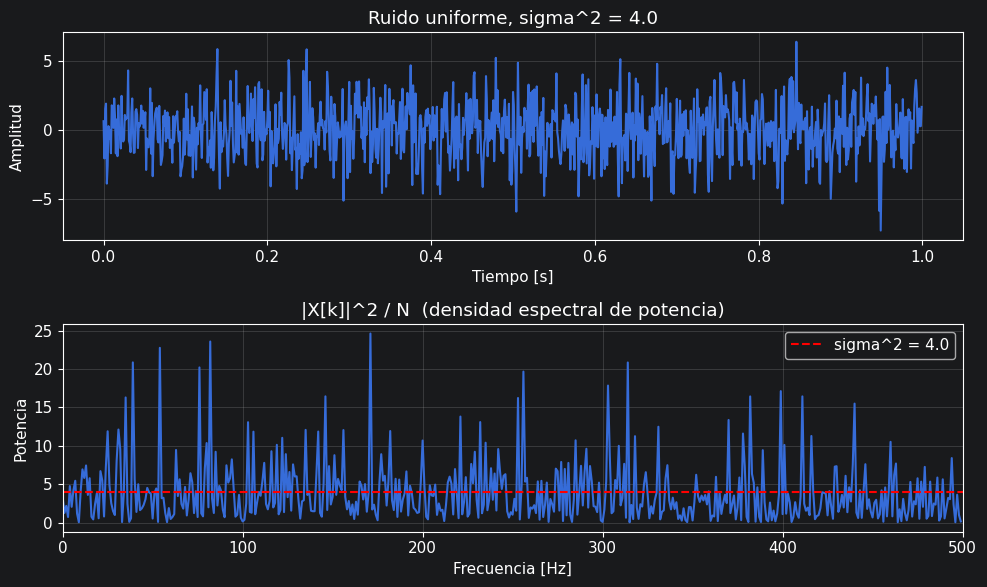


Potencia media estimada: 3.9136   (esperada 3.9102875842432745)


In [8]:
rng = np.random.default_rng(seed=42)

N = 1000
fs = 1000
sigma2 = 4.0

#Scale es sigma
# si se pide sigma**2 = 4 => sigma = 2
ruido = rng.normal(loc=0.0, scale=np.sqrt(sigma2), size=N)


print(f"Varianza:  {np.var(ruido):.4f}   (esperada: {sigma2})")
print(f"Media:    {np.mean(ruido):.4f}   (esperada: 0)")

XX_ruido = mi_funcion_DFT(ruido)
freqs = np.arange(N) * fs / N

potencia = (np.abs(XX_ruido) ** 2) / N

fig, axes = plt.subplots(2, 1, figsize=(10, 6))

axes[0].plot(np.arange(N) / fs, ruido)
axes[0].set_title(f"Ruido uniforme, sigma^2 = {sigma2}")
axes[0].set_xlabel("Tiempo [s]")
axes[0].set_ylabel("Amplitud")

axes[1].plot(freqs[:N//2], potencia[:N//2])
axes[1].axhline(sigma2, color="red", linestyle="--", label=f"sigma^2 = {sigma2}")
axes[1].set_title("|X[k]|^2 / N  (densidad espectral de potencia)")
axes[1].set_xlabel("Frecuencia [Hz]")
axes[1].set_ylabel("Potencia")
axes[1].set_xlim(0, fs/2)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nPotencia media estimada: {np.mean(potencia):.4f}   (esperada {np.var(ruido)})")

# Justificacion teorica

Segun el teorema de parseval, la potencia no se ve alterada en el dominio frecuencial, solamente se redistribuye dentro del espectro.
Esta redistribucion, sigue la siguiente formula:

$$\sum_{n=0}^{N-1} |x[n]|^2 = \frac{1}{N} \sum_{k=0}^{N-1} |X[k]|^2$$

si se divide cada termino por N:
$$\frac{1}{N} \sum_{n=0}^{N-1} |x[n]|^2 = \frac{1}{N^2} \sum_{k=0}^{N-1} |X[k]|^2$$

Sabiendo que la media de la señal es 0 (ruido gaussiano), y teniendo en cuenta:
$$\bar{x} = \frac{1}{N} \sum_{i=1}^{N} x_i$$
ademas de que, para nuestro caso en concreto $\bar{x[n]} = 0$

$$\sigma^2 = \frac{1}{N} \sum_{i=1}^{N} (x_i - \bar{x})^2$$
$$\sigma^2 = \frac{1}{N} \sum_{i=1}^{N} (x_i)^2$$


Se puede resumir el teorema de parseval a lo siguiente:
$$var(x[n]) = mean(\frac{1}{N}|X[k]|^2)$$
